<a href="https://colab.research.google.com/github/Dogatwit/Analysis-of-Virtual-Youtuber/blob/main/VtuberAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [4]:
from google.colab import files
uploaded = files.upload()

Saving masterData.csv to masterData.csv


In [6]:
MANUAL_AFFILIATION_MAP = {
	'@tokoyamitowa' : 'hololive',
	'@minatoaqua' : 'hololive',
	'@hoshimachisuisei' : 'hololive',
	'@oozorasubaru' : 'hololive',
	'@momosuzunene' : 'hololive',
	'@sakuramiko' : 'hololive',
	'@omarupolka' : 'hololive',
	'@robocosan' : 'hololive',
	'@akaihaato' : 'hololive',
	'@nakiriayame' : 'hololive',
	'@houshoumarine': 'hololive',
	'@shishirobotan': 'hololive',
	'@murasakishion': 'hololive',
	'@yuzukichoco' : 'hololive',
	'@ookamimio' : 'hololive',
	'@shirakamifubuki': 'hololive',
	'@inugamikorone': 'hololive',
	'@sakamatachloe' : 'hololive',
	'@hakuikoyori' : 'hololive',
	'@shiranuiflare' : 'hololive',
	'@shiroganenoel': 'hololive',
	'@tokinosora' : 'hololive',
	'@nekomataokayu': 'hololive',
	'@yukihanalamy': 'hololive',
	'@himemoriluna': 'hololive',
	'@akirosenthal' : 'hololive',
	'@laplusdarknesss' : 'hololive',
	'@azki': 'hololive',
	'@takanelui' : 'hololive',
	'@tsunomakiwatame' : 'hololive',
	'@usadapekora' : 'hololive',
	'@natsuiromatsuri' : 'hololive',
	'@amanekanata' : 'hololive',
	'@kazamairoha' : 'hololive',

  '@kageyamashien' : 'HoloStars',
	'@kishidotemma': 'HoloStars',
	'@rikka': 'HoloStars',
	'@yatogamifuma' : 'HoloStars',
	'@kanadeizuru' : 'HoloStars',
	'@hanasakimiyabi': 'HoloStars',
	'@arurandeisu': 'HoloStars',
	'@minaserio' : 'HoloStars',
	'@utsugiuyu': 'HoloStars',
	'@yukokuroberu': 'HoloStars',
	'@astelleda' : 'HoloStars',
	'@aragamioga' : 'Holostars',

  '@uruhaichinose' : 'VSPO!',
	'@hinanotachiba7' : 'VSPO!',


	'@shibuyahal': 'NeoPorte',

  '@plave_official' : 'VLAST',

  '@kenmochitoya' : 'NJISANJI',
  '@suzukautako' : 'NIJISANJI',
  '@hyakumantenbarasalome' : 'NIJISANJI',
	'@inuitoko': 'NIJISANJI',
	'@honmahimawari' : 'NIJISANJI',
	'@sasakisaku' : 'NIJISANJI',
  '@kuzuha': 'NIJISANJI',
	'@ushimiichigo': 'NIJISANJI',
	'@shiinayuika': 'NIJISANJI',
	'@angekatrina': 'NIJISANJI',
	'@mononobealice' : 'NIJISANJI',
	'@yuhiriri': 'NIJISANJI',
	'@tsukinomito': 'NIJISANJI',
	'@kagamihayato': 'NIJISANJI',
	'@lizehelesta' : 'NIJISANJI',
	'@kanae' : 'NIJISANJI',
	'@hoshikawasara' : 'NIJISANJI',
	'@gilzareniii' : 'NIJISANJI',
	'@shizukarin' : 'NIJISANJI',
	'@morinakakazaki' : 'NIJISANJI',

  '@piameraleo-jkt48v': 'JKT48',
	'@tananona-jkt48v' : 'JKT48',
	'@ishakirana-jkt48v' : 'JKT48',
	'@mauranilambari-jkt48v': 'JKT48',
	'@samimaono-jkt48v' : 'JKT48',
	'@kanaiaasa-jkt48v' : 'JKT48',
	'@piameraleo-jkt48v' : 'JKT48',


  '@kohacukch': 'AKA VIRUTAL',
	'@onshannon_': 'AKA VIRTUAL',
	'@gingehenna' : 'AKA VIRTUAL',
	'@viyushiwinko': 'AKA VIRTUAL',
	'@harriscaine' : 'AKA VIRTUAL',
	'@raveanne': 'AKA VIRTUAL',
	'@akeminekomachi' : 'AKA VIRTUAL',
	'@gingehenna' : 'AKA VIRTUAL',
	'@njejessie' : 'AKA VIRTUAL',
	'@karisharl'    : 'AKA VIRTUAL',
	'@violettacalytrix': 'AKA VIRTUAL',
	'@frederett' : 'former AKA VIRTUAL',

	'@dooby3d': 'Independent (Former Hololive)',
	'@niminightmare' : 'Independent (Former Hololive)',
	'@samekosaba' : 'Independent (Former Hololive)',
  '@dokibird' : 'Independent (Former NijiEN)',

  '@haihaloepel' : 'Independent/others',
	'@lortlimbah': 'Independent/others',
  '@filianislost': 'Independent/others',
  '@mythiabatfordch': 'Independent/others',
	'@neurosama': 'Independent/others',
	'@rinpenrose' : 'Independent/others',
	'@caveine' : 'Independent/others',
	'@nimuch' : 'Independent/others',

  '@baovtuber' : 'United Talent',

  '@k9kuro' : 'former Vshoujo',
  '@ironmouseparty' : 'former Vshoujo',
	'@harukakaribu' : 'former Vshoujo',
	'@henyathegenius' : 'former Vshoujo',
	'@apricotfroot' : 'former Vshoujo',
	'@michimochievee' : 'former Vshoujo ',
	'@ksononair' : 'former Vshoujo',
	'@zentreya' : 'former Vshoujo',
	'@geega' : 'former Vshoujo',
	'@himehajime1570': 'former Vshoujo',
	'@matarakan': 'former Vshoujo',

  '@lilpa' : 'USEGYE IDOL',

  '@shylily' : 'Mythic Talent',

	'@ayatsunoyuni':'STELLIVE',
	'@airikanna' : 'STELLIVE'

}

In [7]:
# organized every virtual youtuber into an angency they're with or independent
def detect_affiliation(row):
	text = f"{row['name']} {row['customUrl']}".lower()
	custom_url = row['customUrl'].lower()

	if custom_url in MANUAL_AFFILIATION_MAP:
		return MANUAL_AFFILIATION_MAP[custom_url]
	if 'holostars' in text:
		return 'HoloStars'
	if 'hololive' in text or 'regloss' in text:
		return 'hololive'
	if 'nijisanji' in text or 'にじさんじ' in text:
		return 'NIJISANJI'
	if 'maha5' in text:
		return 'MAHA5'
	if 're:memories' in text:
		return 'Re:Memories'
	if 'phase connect' in text:
		return 'Phase Connect'
	if 'idol' in text and 'corp' in text:
		return 'idol Corp'
	if 'neo-porte' in text or 'neo porte' in text:
		return 'Neo-Porte'
	if 'vspo' in text or 'ぶいすぽ' in text:
		return 'VSPO!'

	return 'Other/Unknown'




In [8]:
def normalize_group(affiliation):
    aff = affiliation.lower()

    if 'hololive' in aff:
        return 'Hololive / Former Hololive'

    return 'Everyone Else'

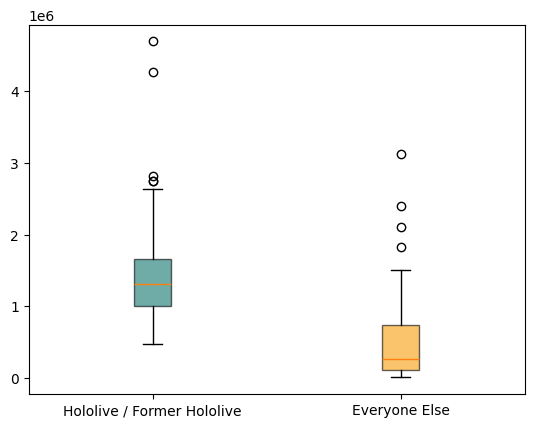

In [9]:
#q1 does being in hololive give you an advantage in popularity?
vtuberdata = pd.read_csv('masterData.csv')
vtuberdata['customUrl'] = vtuberdata['customUrl'].fillna('')
vtuberdata['affiliation'] = vtuberdata.apply(detect_affiliation, axis=1)
vtuberdata['affiliation'] = vtuberdata['affiliation'].apply(normalize_group)
sub_count = vtuberdata.sort_values(by='total_subs', ascending=False)
grouped = vtuberdata.groupby('affiliation')['total_subs']
hololive_subs = grouped.get_group('Hololive / Former Hololive')
everyone_else_subs = grouped.get_group('Everyone Else')
box = plt.boxplot(
    [hololive_subs, everyone_else_subs],
    tick_labels=['Hololive / Former Hololive', 'Everyone Else'],
    patch_artist=True
)

# Soft colors (not overwhelming)
colors = ['#0f766e', '#f59e0b']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

Correlation (subs vs views): 0.6118232768925126
Correlation (subs vs likes): 0.6885379897742988


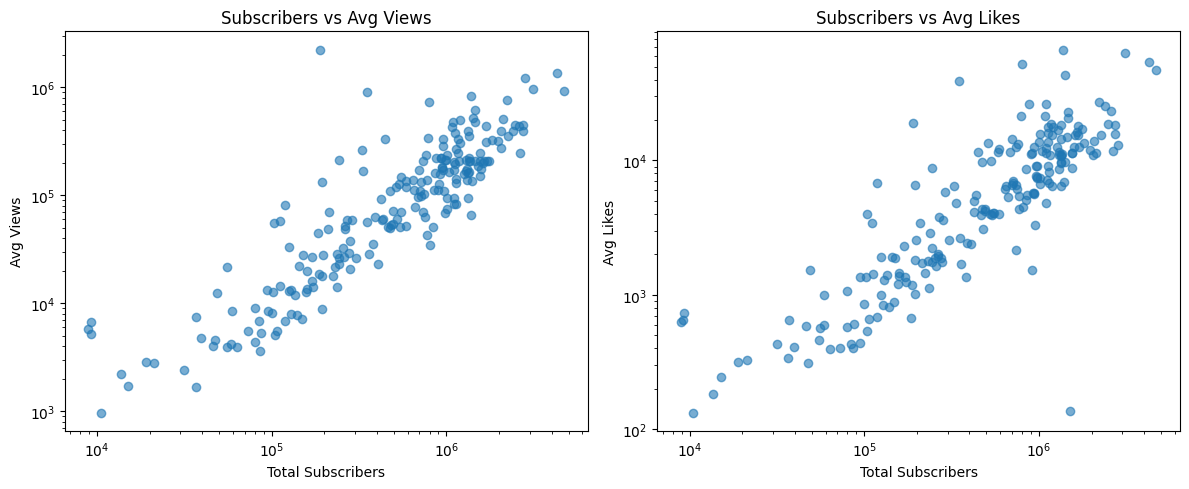

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Views vs Subs
axes[0].scatter(
    vtuberdata['total_subs'],
    vtuberdata['avg_views'],
    alpha=0.6
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Subscribers vs Avg Views')
axes[0].set_xlabel('Total Subscribers')
axes[0].set_ylabel('Avg Views')

# Likes vs Subs
axes[1].scatter(
    vtuberdata['total_subs'],
    vtuberdata['avg_likes'],
    alpha=0.6
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Subscribers vs Avg Likes')
axes[1].set_xlabel('Total Subscribers')
axes[1].set_ylabel('Avg Likes')

print("Correlation (subs vs views):", vtuberdata['total_subs'].corr(vtuberdata['avg_views']))
print("Correlation (subs vs likes):", vtuberdata['total_subs'].corr(vtuberdata['avg_likes']))
plt.tight_layout()